## Preamble

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
nz=201; nx=201

!makevel nz=100 nx=$nx v000=1000 > c1
!makevel nz=101 nx=$nx v000=1800 > c2
!cat c1 c2 > tmp && transp < tmp n1=$nz > simple
!rm c1 c2 tmp

#!makevel nx=201 nz=201 v000=2000 > model

In [53]:
#!cd ../../; sed -i 's/WaveEq=DAS/WaveEq=PSV/' modules.inc
#!make
#!make cleanall; make

#System
(cd ../../Modules/System; make clean)
make[1]: Entering directory '/home/wzhou/Codes/GitHub/SeisJIMU/Modules/System'
rm m_either.o m_string.o m_mpienv.o m_message.o m_arrayop.o m_setup.o m_sysio.o m_checkpoint.o m_suformat.o m_System.o

rm ../../mod/m_either.mod ../../mod/m_string.mod ../../mod/m_mpienv.mod ../../mod/m_message.mod ../../mod/m_arrayop.mod ../../mod/m_setup.mod ../../mod/m_sysio.mod ../../mod/m_checkpoint.mod ../../mod/m_suformat.mod ../../mod/m_System.mod ../../mod/m_system.mod
rm: cannot remove '../../mod/m_System.mod': No such file or directory
make[1]: [Makefile:25: clean] Error 1 (ignored)

make[1]: Leaving directory '/home/wzhou/Codes/GitHub/SeisJIMU/Modules/System'
#Etc
(cd ../../Modules/Etc; make clean)
make[1]: Entering directory '/home/wzhou/Codes/GitHub/SeisJIMU/Modules/Etc'
rm sgtsv.o m_math.o singleton.o

rm ../../mod/m_math.mod ../../mod/singleton.mod

make[1]: Leaving directory '/home/wzhou/Codes/GitHub/SeisJIMU/Modules/Etc'
#Signal
(cd ../../Modul


mpif90 -cpp -Dgfortran -D"git_commit='c925b17'" -D"git_branch='DAS_FS'" -Ofast -fopenmp -ffree-line-length-none -fbacktrace  -fno-unsafe-math-optimizations -frounding-math -fsignaling-nans -J ../../mod/ -c m_pseudotime.f90 -o m_pseudotime.o

mpif90 -cpp -Dgfortran -D"git_commit='c925b17'" -D"git_branch='DAS_FS'" -Ofast -fopenmp -ffree-line-length-none -fbacktrace  -fno-unsafe-math-optimizations -frounding-math -fsignaling-nans -J ../../mod/ -c m_smoother_Laplacian_sparse.f90 -o m_smoother_Laplacian_sparse.o


make[1]: Leaving directory '/home/wzhou/Codes/GitHub/SeisJIMU/Modules/Signal'
#Modeling
(cd ../../Modules/Modeling; make)
make[1]: Entering directory '/home/wzhou/Codes/GitHub/SeisJIMU/Modules/Modeling'
mpif90 -cpp -Dgfortran -D"git_commit='c925b17'" -D"git_branch='DAS_FS'" -Ofast -fopenmp -ffree-line-length-none -fbacktrace  -fno-unsafe-math-optimizations -frounding-math -fsignaling-nans -J ../../mod/ -c m_model.f90 -o m_model.o

mpif90 -cpp -Dgfortran -D"git_commit='c925b17'" -

In [3]:
nt=2000; ntr=100

def read(filename,n=(nx,nz)):
    return np.fromfile(filename,dtype='float32').reshape(n).T

def read_su(filename,n=(ntr,nt)):
    data=read(filename,n=(n[0],int(60+n[1])))
    return data[60:,:]

# def read_snap(filename,n=(nsnap,nxsnap,nzsnap),i=26):
#     tmp=np.fromfile(filename,dtype='float32').reshape(n).T
#     return tmp[:,:,i]

def imshow(data,perc=None,clip=None,clipmin=None,extent=None,cmap='viridis',title=None,grid=True):
    
    if perc==None:
        clipp=[np.amin(data),np.amax(data)]
    else:
        tmp=np.percentile(np.abs(data),q=perc)
        clipp=[-tmp,tmp]
    
    if clip!=None: clipp=clip
    
    if clipmin!=None: clipp[0]=clipmin
    
    plt.imshow(data,vmin=clipp[0],vmax=clipp[1],extent=extent,cmap=cmap,aspect='auto')
    plt.colorbar(location='right')
    plt.grid(visible=grid, axis='both', which='both', color='w', linestyle='--',linewidth=0.5)
    #plt.xlabel(labels[0]); plt.ylabel(labels[1])
    if title!=None: plt.title(title)

## Away from surface

### p-p

#### no Q

In [14]:
!cp setup_default setup
!echo 'T0  0.29' >> setup #=2/fpeak
!echo 'IS_Q_ATTENUATION    F' >> setup

!../../exe/AdjointTest  setup > out

!tail -30 out

 Vector   |       shape       |   ║*║₂
 reS          2000           1  0.206745788    
 imS          2000           1  0.206745535    
 reLS         2000         100   296.966492    
 imLS         2000         100   296.968964    
 reR          2000         100   296.966492    
 imR          2000         100   296.961945    
 reLᴴR        2000           1   488550.562    
 imLᴴR        2000           1   488553.188    
 
 <R|LS> =?= <LᴴR|S>
 LHS= (re  R-iim  R)·(reLS+iimLS) = re  R·reLS + im  R·imLS +i(re  R·imLS - im  R·reLS)
 RHS= (reLᴴR-iimLᴴR)·(re S+iim S) = reLᴴR·re S + imLᴴR·im S +i(reLᴴR·im S - imLᴴR·re S)
 
 Real parts:
 LHS=   44099531.971825548        44098820.835494138        88198352.807319686     
 RHS=   44099549.527537279        44098800.559966400        88198350.087503672     
 Relative diff=  -3.9809292630431338E-007   4.5977482739664126E-007   3.0837492170771310E-008
 
 Imag parts:
 LHS=   845.15520475557923       -1.9592553887668451E-003   845.15716401096802     
 RH

In [15]:
reS   = read_su('results/reS.su',    (1,nt))
imS   = read_su('results/imS.su',    (1,nt))
reLᴴR = read_su('results/reLadjR.su',(1,nt))
imLᴴR = read_su('results/imLadjR.su',(1,nt))

reLS = read_su('results/reLS.su', (ntr,nt))
imLS = read_su('results/imLS.su', (ntr,nt))
reR  = read_su('results/reR.su',  (ntr,nt))
imR  = read_su('results/imR.su',  (ntr,nt))

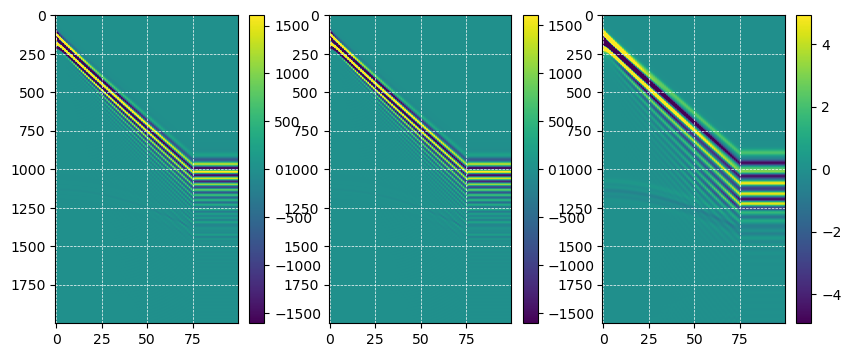

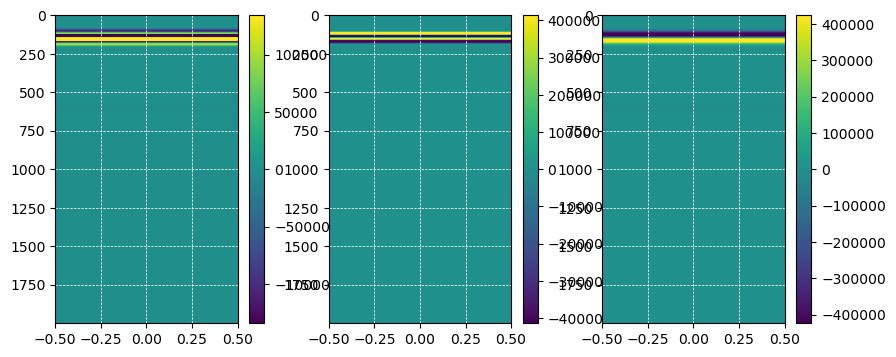

In [16]:
#Imag parts
#LHS
plt.figure(figsize=(10,4))
plt.subplot(1,3,1); imshow( reR*imLS, perc=98)
plt.subplot(1,3,2); imshow( imR*reLS, perc=98)
plt.subplot(1,3,3); imshow( reR*imLS - imR*reLS, perc=98)

#RHS
plt.figure(figsize=(10,4))
plt.subplot(1,3,1); imshow( reLᴴR*imS, perc=98)
plt.subplot(1,3,2); imshow( imLᴴR*reS, perc=98)
plt.subplot(1,3,3); imshow( reLᴴR*imS - imLᴴR*reS, perc=98)

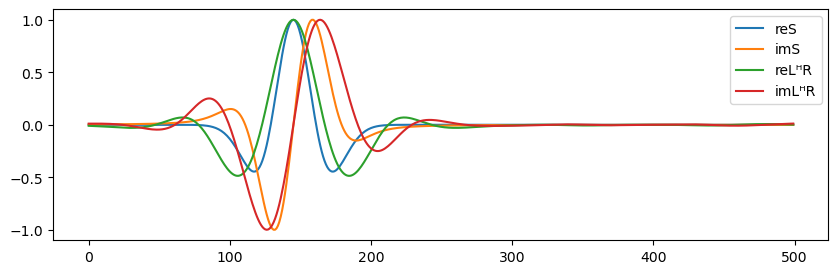

In [17]:
plt.figure(figsize=(10,3))

plt.plot(reS[:500]/reS.max(),label='reS')
plt.plot(imS[:500]/imS.max(),label='imS')

plt.plot(reLᴴR[:500]/reLᴴR.max(),label='reLᴴR')
plt.plot(imLᴴR[:500]/imLᴴR.max(),label='imLᴴR')

plt.legend()

#### Q=1000

In [18]:
nz=201; nx=201

!makevel nz=$nz nx=$nx v000=1000 > qp1000
!cat simple qp1000 > simple_qp

In [19]:
!cp setup_default setup
!echo 'T0  0.29' >> setup #=2/fpeak
!echo 'FILE_MODEL   simple_qp' >> setup
!echo "MODEL_ATTRIBUTES     'vp qp'" >> setup
#!echo 'IS_Q_ATTENUATION    F' >> setup

!../../exe/AdjointTest  setup > out

!tail -30 out

 Vector   |       shape       |   ║*║₂
 reS          2000           1  0.206745788    
 imS          2000           1  0.206745535    
 reLS         2000         100   289.623840    
 imLS         2000         100   289.619873    
 reR          2000         100   289.623840    
 imR          2000         100   289.615173    
 reLᴴR        2000           1   467436.969    
 imLᴴR        2000           1   467444.562    
 
 <R|LS> =?= <LᴴR|S>
 LHS= (re  R-iim  R)·(reLS+iimLS) = re  R·reLS + im  R·imLS +i(re  R·imLS - im  R·reLS)
 RHS= (reLᴴR-iimLᴴR)·(re S+iim S) = reLᴴR·re S + imLᴴR·im S +i(reLᴴR·im S - imLᴴR·re S)
 
 Real parts:
 LHS=   41945773.509273939        41945153.711204723        83890927.220478654     
 RHS=   41945783.586976185        41945182.785041071        83890966.372017264     
 Relative diff=  -2.4025548710833133E-007  -6.9313934451465433E-007  -4.6669574300403101E-007
 
 Imag parts:
 LHS=   893.36297681992301       -2.2637889119403454E-003   893.36524060883494     
 RH

In [20]:
reS   = read_su('results/reS.su',    (1,nt))
imS   = read_su('results/imS.su',    (1,nt))
reLᴴR = read_su('results/reLadjR.su',(1,nt))
imLᴴR = read_su('results/imLadjR.su',(1,nt))

reLS = read_su('results/reLS.su', (ntr,nt))
imLS = read_su('results/imLS.su', (ntr,nt))
reR  = read_su('results/reR.su',  (ntr,nt))
imR  = read_su('results/imR.su',  (ntr,nt))

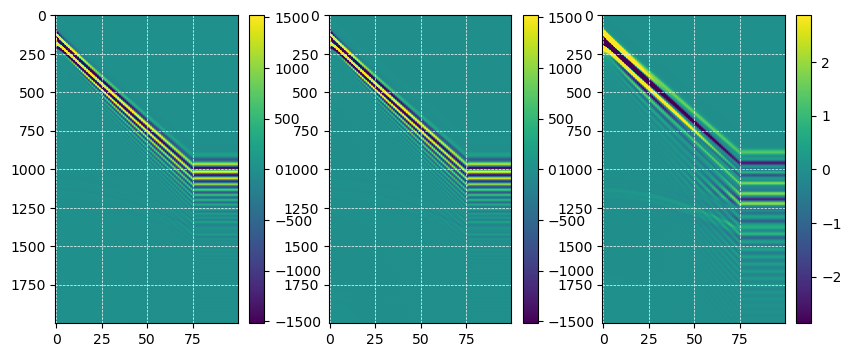

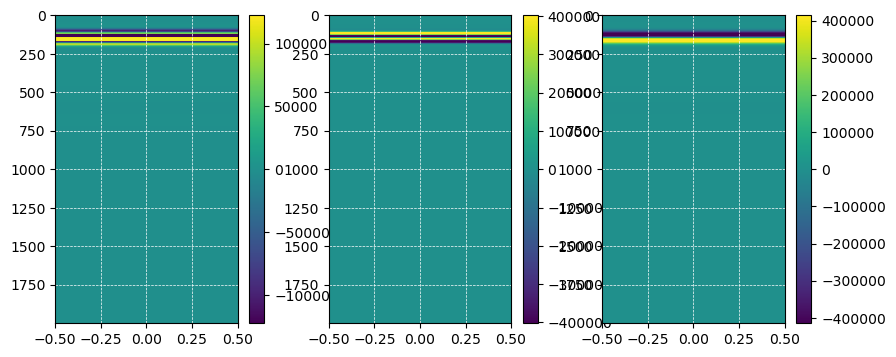

In [21]:
#Imag parts
#LHS
plt.figure(figsize=(10,4))
plt.subplot(1,3,1); imshow( reR*imLS, perc=98)
plt.subplot(1,3,2); imshow( imR*reLS, perc=98)
plt.subplot(1,3,3); imshow( reR*imLS - imR*reLS, perc=98)

#RHS
plt.figure(figsize=(10,4))
plt.subplot(1,3,1); imshow( reLᴴR*imS, perc=98)
plt.subplot(1,3,2); imshow( imLᴴR*reS, perc=98)
plt.subplot(1,3,3); imshow( reLᴴR*imS - imLᴴR*reS, perc=98)

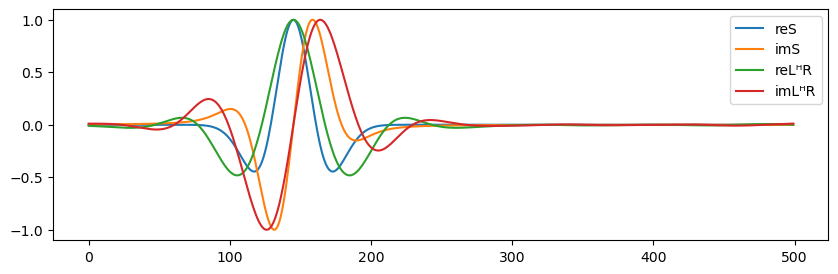

In [22]:
plt.figure(figsize=(10,3))

plt.plot(reS[:500]/reS.max(),label='reS')
plt.plot(imS[:500]/imS.max(),label='imS')

plt.plot(reLᴴR[:500]/reLᴴR.max(),label='reLᴴR')
plt.plot(imLᴴR[:500]/imLᴴR.max(),label='imLᴴR')

plt.legend()

#### Q=100

In [23]:
nz=201; nx=201

!makevel nz=$nz nx=$nx v000=100 > qp100
!cat simple qp100 > simple_qp

In [24]:
!cp setup_default setup
!echo 'T0  0.29' >> setup #=2/fpeak
!echo 'FILE_MODEL   simple_qp' >> setup
!echo "MODEL_ATTRIBUTES     'vp qp'" >> setup
#!echo 'IS_Q_ATTENUATION    F' >> setup

!../../exe/AdjointTest  setup > out

!tail -30 out

 Vector   |       shape       |   ║*║₂
 reS          2000           1  0.206745788    
 imS          2000           1  0.206745535    
 reLS         2000         100   237.423065    
 imLS         2000         100   237.422897    
 reR          2000         100   237.423065    
 imR          2000         100   237.423813    
 reLᴴR        2000           1   329408.969    
 imLᴴR        2000           1   329447.781    
 
 <R|LS> =?= <LᴴR|S>
 LHS= (re  R-iim  R)·(reLS+iimLS) = re  R·reLS + im  R·imLS +i(re  R·imLS - im  R·reLS)
 RHS= (reLᴴR-iimLᴴR)·(re S+iim S) = reLᴴR·re S + imLᴴR·im S +i(reLᴴR·im S - imLᴴR·re S)
 
 Real parts:
 LHS=   28191126.477205344        28186627.295007575        56377753.772212923     
 RHS=   28188922.966259599        28188833.203525886        56377756.169785485     
 Relative diff=   7.8163281184471923E-005  -7.8260818338536989E-005  -4.2526925989027288E-008
 
 Imag parts:
 LHS=   780.11630850887980       -1.1393347306366486E-002   780.12770185618615     
 RH

In [25]:
reS   = read_su('results/reS.su',    (1,nt))
imS   = read_su('results/imS.su',    (1,nt))
reLᴴR = read_su('results/reLadjR.su',(1,nt))
imLᴴR = read_su('results/imLadjR.su',(1,nt))

reLS = read_su('results/reLS.su', (ntr,nt))
imLS = read_su('results/imLS.su', (ntr,nt))
reR  = read_su('results/reR.su',  (ntr,nt))
imR  = read_su('results/imR.su',  (ntr,nt))

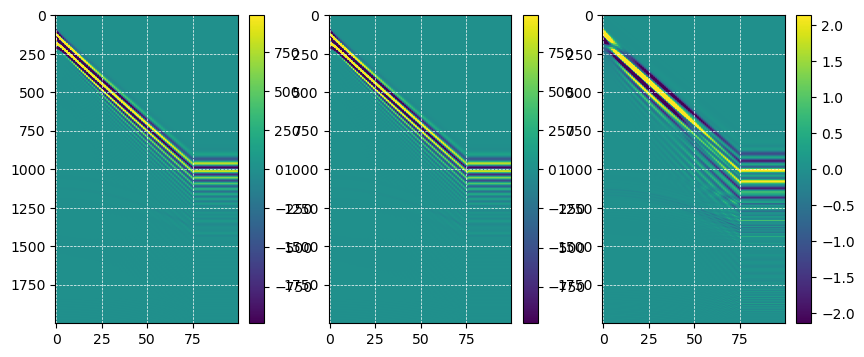

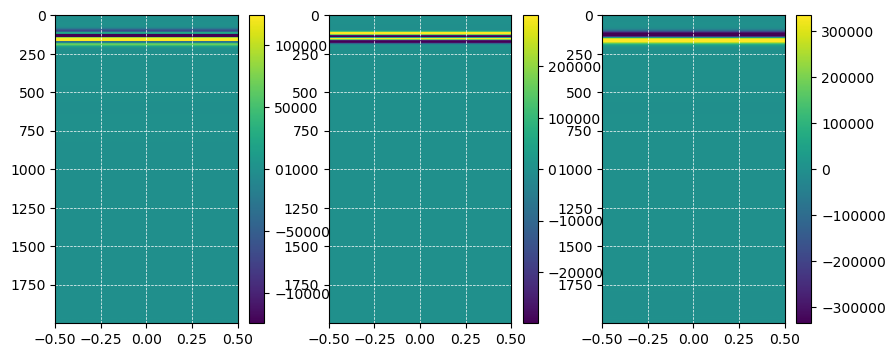

In [26]:
#Imag parts
#LHS
plt.figure(figsize=(10,4))
plt.subplot(1,3,1); imshow( reR*imLS, perc=98)
plt.subplot(1,3,2); imshow( imR*reLS, perc=98)
plt.subplot(1,3,3); imshow( reR*imLS - imR*reLS, perc=98)

#RHS
plt.figure(figsize=(10,4))
plt.subplot(1,3,1); imshow( reLᴴR*imS, perc=98)
plt.subplot(1,3,2); imshow( imLᴴR*reS, perc=98)
plt.subplot(1,3,3); imshow( reLᴴR*imS - imLᴴR*reS, perc=98)

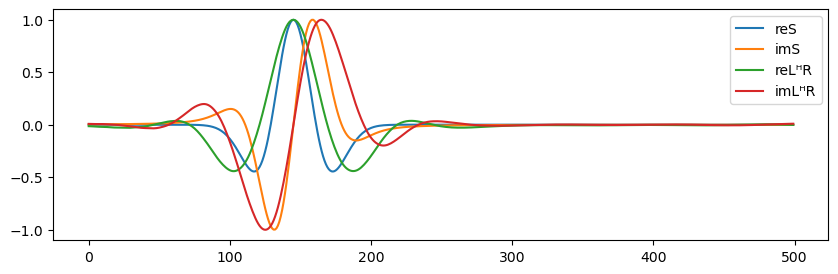

In [27]:
plt.figure(figsize=(10,3))

plt.plot(reS[:500]/reS.max(),label='reS')
plt.plot(imS[:500]/imS.max(),label='imS')

plt.plot(reLᴴR[:500]/reLᴴR.max(),label='reLᴴR')
plt.plot(imLᴴR[:500]/imLᴴR.max(),label='imLᴴR')

plt.legend()

### dpdz-p

#### no Q

In [28]:
!cp setup_default setup
!echo 'T0  0.29' >> setup #=2/fpeak
!echo 'IS_Q_ATTENUATION    F' >> setup

!echo "SCOMP    dpdz" >> setup

!../../exe/AdjointTest  setup > out

!tail -30 out

 Vector   |       shape       |   ║*║₂
 reS          2000           1  0.206745788    
 imS          2000           1  0.206745535    
 reLS         2000         100   6.03736591    
 imLS         2000         100   6.03700018    
 reR          2000         100   6.03736591    
 imR          2000         100   6.03723431    
 reLᴴR        2000           1   194.287979    
 imLᴴR        2000           1   194.283554    
 
 <R|LS> =?= <LᴴR|S>
 LHS= (re  R-iim  R)·(reLS+iimLS) = re  R·reLS + im  R·imLS +i(re  R·imLS - im  R·reLS)
 RHS= (reLᴴR-iimLᴴR)·(re S+iim S) = reLᴴR·re S + imLᴴR·im S +i(reLᴴR·im S - imLᴴR·re S)
 
 Real parts:
 LHS=   18226.063651961653        18225.171616346437        36451.235268308090     
 RHS=   18226.052524353592        18225.178539537988        36451.231063891581     
 Relative diff=   6.1053271145771574E-007  -3.7986975909260018E-007   1.1534359476057889E-007
 
 Imag parts:
 LHS= -0.41792939188762135       -3.7212068363622064E-006 -0.41792567068078501     
 RH

In [29]:
reS   = read_su('results/reS.su',    (1,nt))
imS   = read_su('results/imS.su',    (1,nt))
reLᴴR = read_su('results/reLadjR.su',(1,nt))
imLᴴR = read_su('results/imLadjR.su',(1,nt))

reLS = read_su('results/reLS.su', (ntr,nt))
imLS = read_su('results/imLS.su', (ntr,nt))
reR  = read_su('results/reR.su',  (ntr,nt))
imR  = read_su('results/imR.su',  (ntr,nt))

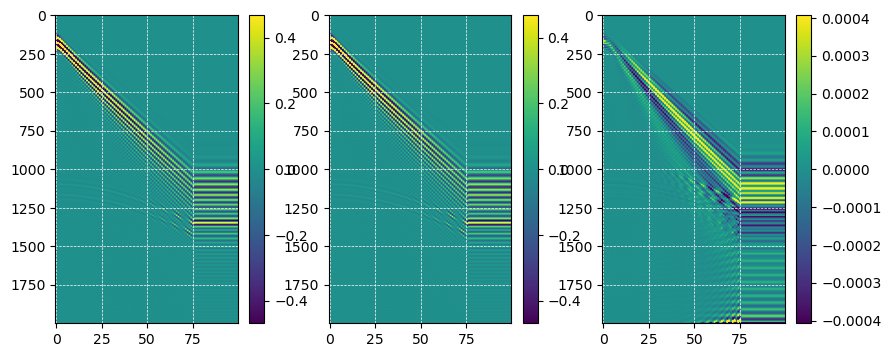

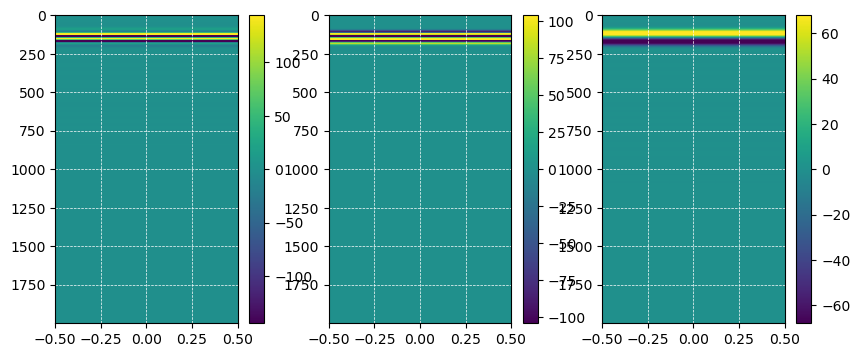

In [30]:
#Imag parts
#LHS
plt.figure(figsize=(10,4))
plt.subplot(1,3,1); imshow( reR*imLS, perc=98)
plt.subplot(1,3,2); imshow( imR*reLS, perc=98)
plt.subplot(1,3,3); imshow( reR*imLS - imR*reLS, perc=98)

#RHS
plt.figure(figsize=(10,4))
plt.subplot(1,3,1); imshow( reLᴴR*imS, perc=98)
plt.subplot(1,3,2); imshow( imLᴴR*reS, perc=98)
plt.subplot(1,3,3); imshow( reLᴴR*imS - imLᴴR*reS, perc=98)

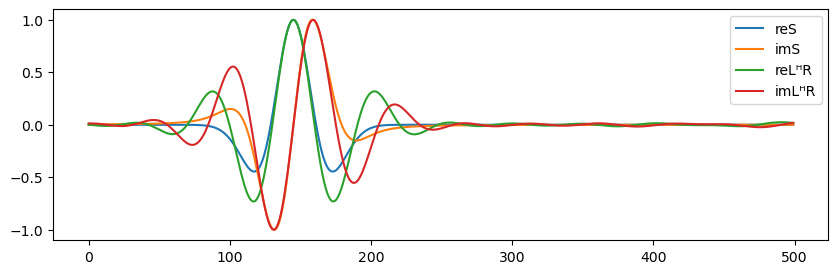

In [31]:
plt.figure(figsize=(10,3))

plt.plot(reS[:500]/reS.max(),label='reS')
plt.plot(imS[:500]/imS.max(),label='imS')

plt.plot(reLᴴR[:500]/reLᴴR.max(),label='reLᴴR')
plt.plot(imLᴴR[:500]/imLᴴR.max(),label='imLᴴR')

plt.legend()

#### Q=100

In [32]:
nz=201; nx=201

!makevel nz=$nz nx=$nx v000=100 > qp100
!cat simple qp100 > simple_qp

In [33]:
!cp setup_default setup
!echo 'T0  0.29' >> setup #=2/fpeak
!echo 'FILE_MODEL   simple_qp' >> setup
!echo "MODEL_ATTRIBUTES     'vp qp'" >> setup

!echo "SCOMP    dpdz" >> setup

!../../exe/AdjointTest  setup > out

!tail -30 out

 Vector   |       shape       |   ║*║₂
 reS          2000           1  0.206745788    
 imS          2000           1  0.206745535    
 reLS         2000         100   4.40839148    
 imLS         2000         100   4.40852499    
 reR          2000         100   4.40839148    
 imR          2000         100   4.40841246    
 reLᴴR        2000           1   100.580490    
 imLᴴR        2000           1   100.580948    
 
 <R|LS> =?= <LᴴR|S>
 LHS= (re  R-iim  R)·(reLS+iimLS) = re  R·reLS + im  R·imLS +i(re  R·imLS - im  R·reLS)
 RHS= (reLᴴR-iimLᴴR)·(re S+iim S) = reLᴴR·re S + imLᴴR·im S +i(reLᴴR·im S - imLᴴR·re S)
 
 Real parts:
 LHS=   9718.7903913463415        9708.7679936620370        19427.558385008379     
 RHS=   9713.7592868896991        9713.7940187411405        19427.553305630841     
 Relative diff=   5.1766776049848187E-004  -5.1767897661005491E-004   2.6145218233421366E-007
 
 Imag parts:
 LHS=   3.7534224013032587E-002   6.3174939446300309E-008   3.7534160838093140E-002
 RH

Imag part is less good (-0.46)

In [34]:
reS   = read_su('results/reS.su',    (1,nt))
imS   = read_su('results/imS.su',    (1,nt))
reLᴴR = read_su('results/reLadjR.su',(1,nt))
imLᴴR = read_su('results/imLadjR.su',(1,nt))

reLS = read_su('results/reLS.su', (ntr,nt))
imLS = read_su('results/imLS.su', (ntr,nt))
reR  = read_su('results/reR.su',  (ntr,nt))
imR  = read_su('results/imR.su',  (ntr,nt))

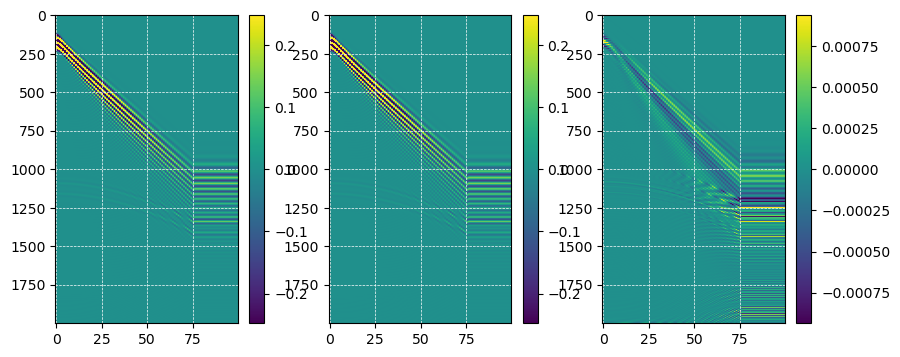

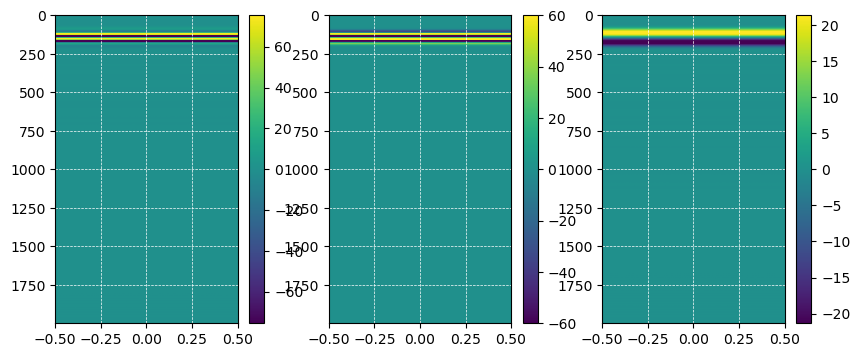

In [35]:
#Imag parts
#LHS
plt.figure(figsize=(10,4))
plt.subplot(1,3,1); imshow( reR*imLS, perc=98)
plt.subplot(1,3,2); imshow( imR*reLS, perc=98)
plt.subplot(1,3,3); imshow( reR*imLS - imR*reLS, perc=98)

#RHS
plt.figure(figsize=(10,4))
plt.subplot(1,3,1); imshow( reLᴴR*imS, perc=98)
plt.subplot(1,3,2); imshow( imLᴴR*reS, perc=98)
plt.subplot(1,3,3); imshow( reLᴴR*imS - imLᴴR*reS, perc=98)

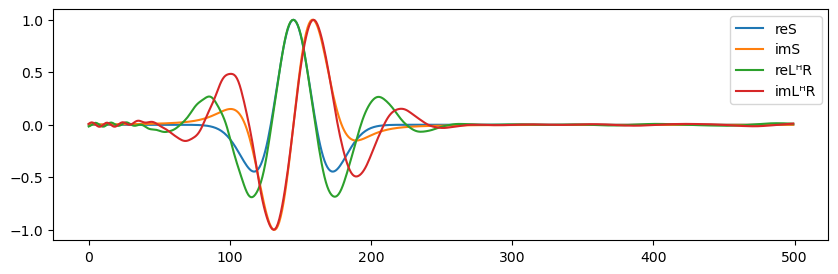

In [36]:
plt.figure(figsize=(10,3))

plt.plot(reS[:500]/reS.max(),label='reS')
plt.plot(imS[:500]/imS.max(),label='imS')

plt.plot(reLᴴR[:500]/reLᴴR.max(),label='reLᴴR')
plt.plot(imLᴴR[:500]/imLᴴR.max(),label='imLᴴR')

plt.legend()

### p-dpdz

#### no Q

In [37]:
!cp setup_default setup
!echo 'T0  0.29' >> setup #=2/fpeak
!echo 'IS_Q_ATTENUATION    F' >> setup

!echo "RCOMP    dpdz" >> setup

!../../exe/AdjointTest  setup > out

!tail -30 out

 Vector   |       shape       |   ║*║₂
 reS          2000           1  0.206745788    
 imS          2000           1  0.206745535    
 reLS         2000         100   6.03737068    
 imLS         2000         100   6.03700352    
 reR          2000         100   6.03737068    
 imR          2000         100   6.03722620    
 reLᴴR        2000           1   194.287994    
 imLᴴR        2000           1   194.283508    
 
 <R|LS> =?= <LᴴR|S>
 LHS= (re  R-iim  R)·(reLS+iimLS) = re  R·reLS + im  R·imLS +i(re  R·imLS - im  R·reLS)
 RHS= (reLᴴR-iimLᴴR)·(re S+iim S) = reLᴴR·re S + imLᴴR·im S +i(reLᴴR·im S - imLᴴR·re S)
 
 Real parts:
 LHS=   18226.055105841409        18225.170496941540        36451.225602782950     
 RHS=   18226.051028070218        18225.177029673385        36451.228057743603     
 Relative diff=   2.2373306606380533E-007  -3.5844558191877541E-007  -6.7349193687465640E-008
 
 Imag parts:
 LHS= -0.41572323156498436       -2.4757423740390250E-006 -0.41572075582261031     
 RH

In [38]:
reS   = read_su('results/reS.su',    (1,nt))
imS   = read_su('results/imS.su',    (1,nt))
reLᴴR = read_su('results/reLadjR.su',(1,nt))
imLᴴR = read_su('results/imLadjR.su',(1,nt))

reLS = read_su('results/reLS.su', (ntr,nt))
imLS = read_su('results/imLS.su', (ntr,nt))
reR  = read_su('results/reR.su',  (ntr,nt))
imR  = read_su('results/imR.su',  (ntr,nt))

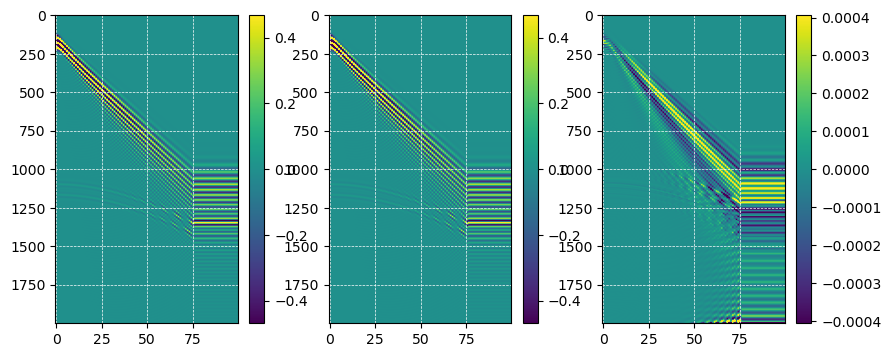

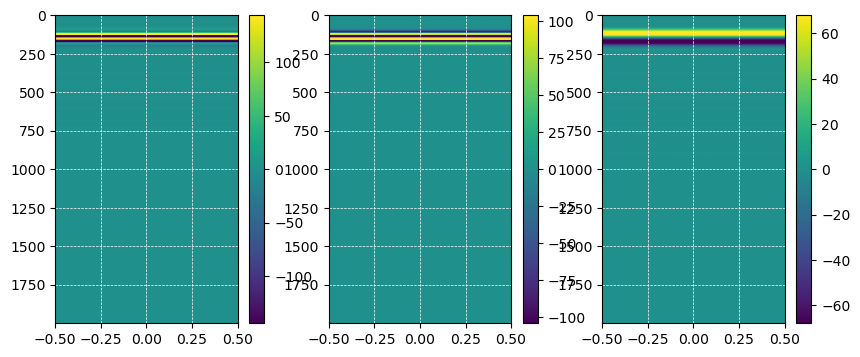

In [39]:
#Imag parts
#LHS
plt.figure(figsize=(10,4))
plt.subplot(1,3,1); imshow( reR*imLS, perc=98)
plt.subplot(1,3,2); imshow( imR*reLS, perc=98)
plt.subplot(1,3,3); imshow( reR*imLS - imR*reLS, perc=98)

#RHS
plt.figure(figsize=(10,4))
plt.subplot(1,3,1); imshow( reLᴴR*imS, perc=98)
plt.subplot(1,3,2); imshow( imLᴴR*reS, perc=98)
plt.subplot(1,3,3); imshow( reLᴴR*imS - imLᴴR*reS, perc=98)

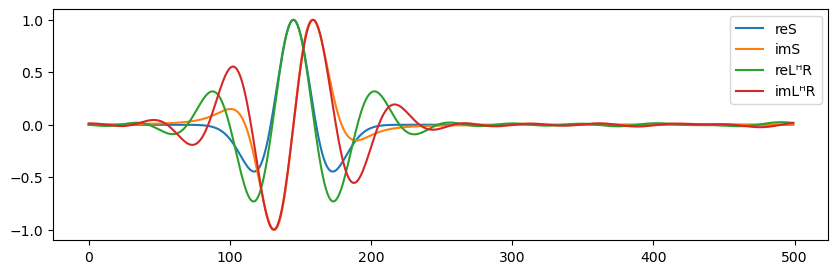

In [40]:
plt.figure(figsize=(10,3))

plt.plot(reS[:500]/reS.max(),label='reS')
plt.plot(imS[:500]/imS.max(),label='imS')

plt.plot(reLᴴR[:500]/reLᴴR.max(),label='reLᴴR')
plt.plot(imLᴴR[:500]/imLᴴR.max(),label='imLᴴR')

plt.legend()

#### Q=100

In [41]:
nz=201; nx=201

!makevel nz=$nz nx=$nx v000=100 > qp100
!cat simple qp100 > simple_qp

In [42]:
!cp setup_default setup
!echo 'T0  0.29' >> setup #=2/fpeak
!echo 'FILE_MODEL   simple_qp' >> setup
!echo "MODEL_ATTRIBUTES     'vp qp'" >> setup
!echo 'IS_Q_ATTENUATION    F' >> setup

!echo "RCOMP    dpdz" >> setup

!../../exe/AdjointTest  setup > out

!tail -30 out

 Vector   |       shape       |   ║*║₂
 reS          2000           1  0.206745788    
 imS          2000           1  0.206745535    
 reLS         2000         100   6.03737068    
 imLS         2000         100   6.03700352    
 reR          2000         100   6.03737068    
 imR          2000         100   6.03722620    
 reLᴴR        2000           1   194.287994    
 imLᴴR        2000           1   194.283508    
 
 <R|LS> =?= <LᴴR|S>
 LHS= (re  R-iim  R)·(reLS+iimLS) = re  R·reLS + im  R·imLS +i(re  R·imLS - im  R·reLS)
 RHS= (reLᴴR-iimLᴴR)·(re S+iim S) = reLᴴR·re S + imLᴴR·im S +i(reLᴴR·im S - imLᴴR·re S)
 
 Real parts:
 LHS=   18226.055105841409        18225.170496941540        36451.225602782950     
 RHS=   18226.051028070218        18225.177029673385        36451.228057743603     
 Relative diff=   2.2373306606380533E-007  -3.5844558191877541E-007  -6.7349193687465640E-008
 
 Imag parts:
 LHS= -0.41572323156498436       -2.4757423740390250E-006 -0.41572075582261031     
 RH

In [43]:
reS   = read_su('results/reS.su',    (1,nt))
imS   = read_su('results/imS.su',    (1,nt))
reLᴴR = read_su('results/reLadjR.su',(1,nt))
imLᴴR = read_su('results/imLadjR.su',(1,nt))

reLS = read_su('results/reLS.su', (ntr,nt))
imLS = read_su('results/imLS.su', (ntr,nt))
reR  = read_su('results/reR.su',  (ntr,nt))
imR  = read_su('results/imR.su',  (ntr,nt))

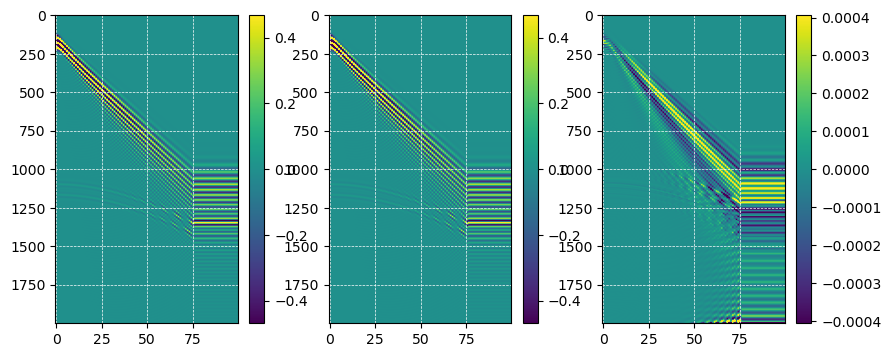

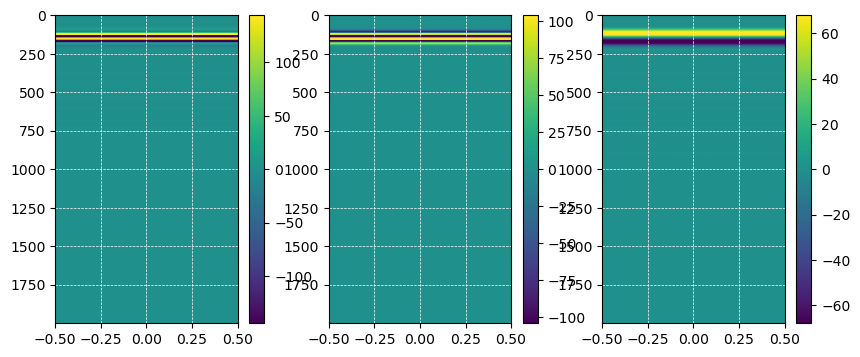

In [44]:
#Imag parts
#LHS
plt.figure(figsize=(10,4))
plt.subplot(1,3,1); imshow( reR*imLS, perc=98)
plt.subplot(1,3,2); imshow( imR*reLS, perc=98)
plt.subplot(1,3,3); imshow( reR*imLS - imR*reLS, perc=98)

#RHS
plt.figure(figsize=(10,4))
plt.subplot(1,3,1); imshow( reLᴴR*imS, perc=98)
plt.subplot(1,3,2); imshow( imLᴴR*reS, perc=98)
plt.subplot(1,3,3); imshow( reLᴴR*imS - imLᴴR*reS, perc=98)

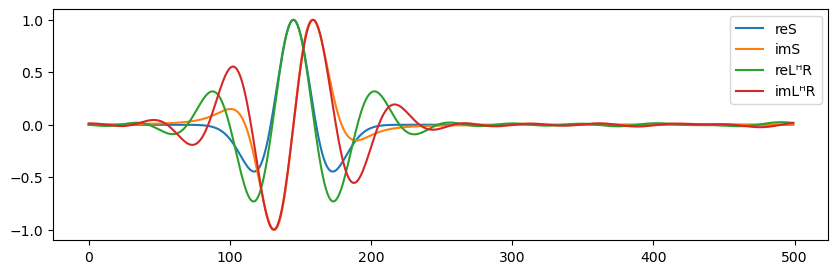

In [45]:
plt.figure(figsize=(10,3))

plt.plot(reS[:500]/reS.max(),label='reS')
plt.plot(imS[:500]/imS.max(),label='imS')

plt.plot(reLᴴR[:500]/reLᴴR.max(),label='reLᴴR')
plt.plot(imLᴴR[:500]/imLᴴR.max(),label='imLᴴR')

plt.legend()

### dpdz-dpdz

#### no Q

In [46]:
!cp setup_default setup
!echo 'T0  0.29' >> setup #=2/fpeak
!echo 'IS_Q_ATTENUATION    F' >> setup

!echo "SCOMP    dpdz" >> setup
!echo "RCOMP    dpdz" >> setup

!../../exe/AdjointTest  setup > out

!tail -30 out

 Vector   |       shape       |   ║*║₂
 reS          2000           1  0.206745788    
 imS          2000           1  0.206745535    
 reLS         2000         100  0.420453966    
 imLS         2000         100  0.420445085    
 reR          2000         100  0.420453966    
 imR          2000         100  0.420448929    
 reLᴴR        2000           1  0.871053517    
 imLᴴR        2000           1  0.870979249    
 
 <R|LS> =?= <LᴴR|S>
 LHS= (re  R-iim  R)·(reLS+iimLS) = re  R·reLS + im  R·imLS +i(re  R·imLS - im  R·reLS)
 RHS= (reLᴴR-iimLᴴR)·(re S+iim S) = reLᴴR·re S + imLᴴR·im S +i(reLᴴR·im S - imLᴴR·re S)
 
 Real parts:
 LHS=   88.409880112056925        88.405930523320180        176.81581063537709     
 RHS=   88.409880681520860        88.405938108620091        176.81581879014095     
 Relative diff=  -6.4411798188242574E-009  -8.5800803937444439E-008  -4.6120105618430722E-008
 
 Imag parts:
 LHS=   9.4840521231891216E-004   7.4078107417235037E-008   9.4833113421149496E-004
 RH

In [47]:
reS   = read_su('results/reS.su',    (1,nt))
imS   = read_su('results/imS.su',    (1,nt))
reLᴴR = read_su('results/reLadjR.su',(1,nt))
imLᴴR = read_su('results/imLadjR.su',(1,nt))

reLS = read_su('results/reLS.su', (ntr,nt))
imLS = read_su('results/imLS.su', (ntr,nt))
reR  = read_su('results/reR.su',  (ntr,nt))
imR  = read_su('results/imR.su',  (ntr,nt))

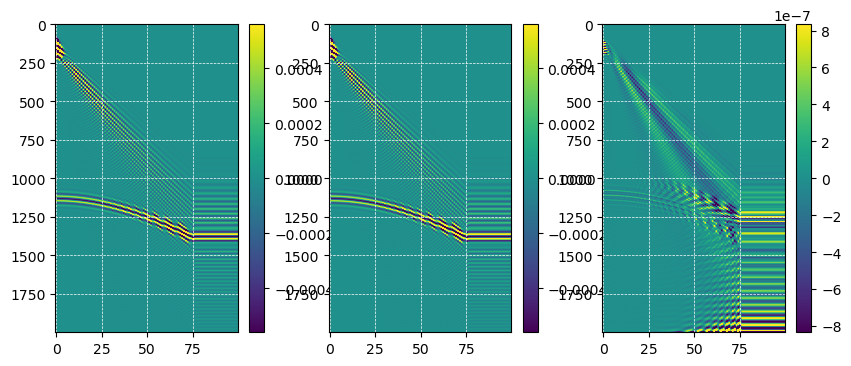

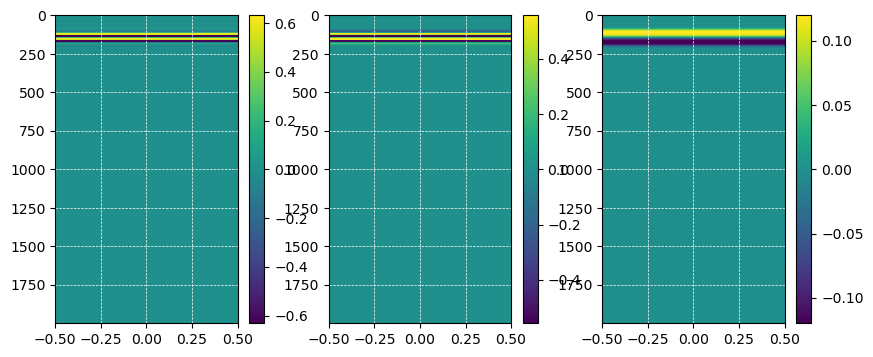

In [48]:
#Imag parts
#LHS
plt.figure(figsize=(10,4))
plt.subplot(1,3,1); imshow( reR*imLS, perc=98)
plt.subplot(1,3,2); imshow( imR*reLS, perc=98)
plt.subplot(1,3,3); imshow( reR*imLS - imR*reLS, perc=98)

#RHS
plt.figure(figsize=(10,4))
plt.subplot(1,3,1); imshow( reLᴴR*imS, perc=98)
plt.subplot(1,3,2); imshow( imLᴴR*reS, perc=98)
plt.subplot(1,3,3); imshow( reLᴴR*imS - imLᴴR*reS, perc=98)

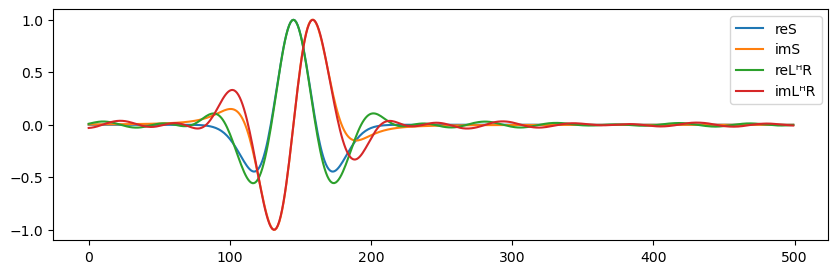

In [49]:
plt.figure(figsize=(10,3))

plt.plot(reS[:500]/reS.max(),label='reS')
plt.plot(imS[:500]/imS.max(),label='imS')

plt.plot(reLᴴR[:500]/reLᴴR.max(),label='reLᴴR')
plt.plot(imLᴴR[:500]/imLᴴR.max(),label='imLᴴR')

plt.legend()

#### Q=100

In [50]:
nz=201; nx=201

!makevel nz=$nz nx=$nx v000=100 > qp100
!cat simple qp100 > simple_qp

In [51]:
!cp setup_default setup
!echo 'T0  0.29' >> setup #=2/fpeak
!echo 'FILE_MODEL   simple_qp' >> setup
!echo "MODEL_ATTRIBUTES     'vp qp'" >> setup
!echo 'IS_Q_ATTENUATION    F' >> setup

!echo "SCOMP    dpdz" >> setup
!echo "RCOMP    dpdz" >> setup

!../../exe/AdjointTest  setup > out

!tail -30 out

 Vector   |       shape       |   ║*║₂
 reS          2000           1  0.206745788    
 imS          2000           1  0.206745535    
 reLS         2000         100  0.420453966    
 imLS         2000         100  0.420445085    
 reR          2000         100  0.420453966    
 imR          2000         100  0.420448929    
 reLᴴR        2000           1  0.871053517    
 imLᴴR        2000           1  0.870979249    
 
 <R|LS> =?= <LᴴR|S>
 LHS= (re  R-iim  R)·(reLS+iimLS) = re  R·reLS + im  R·imLS +i(re  R·imLS - im  R·reLS)
 RHS= (reLᴴR-iimLᴴR)·(re S+iim S) = reLᴴR·re S + imLᴴR·im S +i(reLᴴR·im S - imLᴴR·re S)
 
 Real parts:
 LHS=   88.409880112056925        88.405930523320180        176.81581063537709     
 RHS=   88.409880681520860        88.405938108620091        176.81581879014095     
 Relative diff=  -6.4411798188242574E-009  -8.5800803937444439E-008  -4.6120105618430722E-008
 
 Imag parts:
 LHS=   9.4840521231891216E-004   7.4078107417235037E-008   9.4833113421149496E-004
 RH

In [52]:
reS   = read_su('results/reS.su',    (1,nt))
imS   = read_su('results/imS.su',    (1,nt))
reLᴴR = read_su('results/reLadjR.su',(1,nt))
imLᴴR = read_su('results/imLadjR.su',(1,nt))

reLS = read_su('results/reLS.su', (ntr,nt))
imLS = read_su('results/imLS.su', (ntr,nt))
reR  = read_su('results/reR.su',  (ntr,nt))
imR  = read_su('results/imR.su',  (ntr,nt))

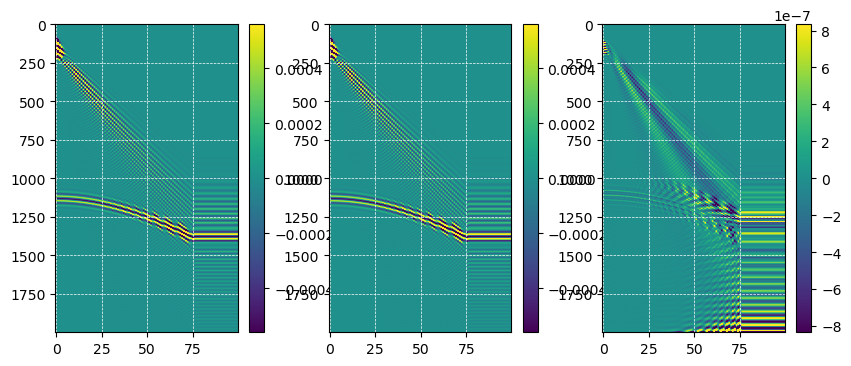

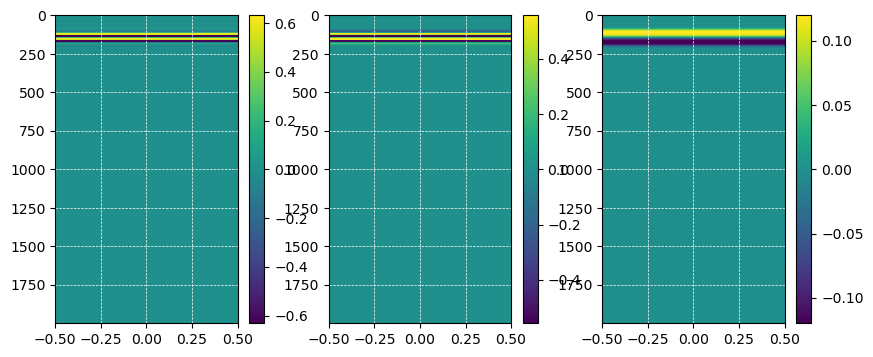

In [53]:
#Imag parts
#LHS
plt.figure(figsize=(10,4))
plt.subplot(1,3,1); imshow( reR*imLS, perc=98)
plt.subplot(1,3,2); imshow( imR*reLS, perc=98)
plt.subplot(1,3,3); imshow( reR*imLS - imR*reLS, perc=98)

#RHS
plt.figure(figsize=(10,4))
plt.subplot(1,3,1); imshow( reLᴴR*imS, perc=98)
plt.subplot(1,3,2); imshow( imLᴴR*reS, perc=98)
plt.subplot(1,3,3); imshow( reLᴴR*imS - imLᴴR*reS, perc=98)

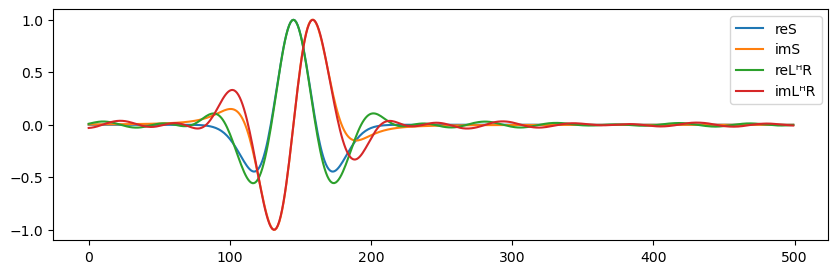

In [54]:
plt.figure(figsize=(10,3))

plt.plot(reS[:500]/reS.max(),label='reS')
plt.plot(imS[:500]/imS.max(),label='imS')

plt.plot(reLᴴR[:500]/reLᴴR.max(),label='reLᴴR')
plt.plot(imLᴴR[:500]/imLᴴR.max(),label='imLᴴR')

plt.legend()